# EE4211 Project (Group 21)
----
## Question 1: Data Cleaning & Exploring the Data

In [2]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import requests
from datetime import datetime, timedelta
import time
import numpy as np

### 1.1 What do the values in the column "lot type" mean?
----
Lot type refers to the type of vehicles the car park can house. According to the official API documentation, the standard types are: **C** (Cars), **H** (Heavy vehicles), **S** (Motorcycles with side car), **Y** (Motorcycles).

However, analysis of the dataset reveals additional undocumented lot types:

**Lot type 'L' (Undocumented - Deprecated):**

From analyzing the df_collection.json file, lot type 'L' appears only for one carpark:
- Carpark: SE12 (Blk 211-222 Serangoon Ave 4)
- Timestamp: 2022-10-05 (historical snapshot)
- Capacity: 0 total lots, 0 available lots
- Context: Appeared alongside lot types M and S (also with 0 lots)
- Current status: By 2024, SE12 only shows type C lots (722 total)

This suggests type 'L' is a deprecated classification, a placeholder during carpark reconfiguration, or a rarely-implemented designation.

**Lot type 'M' (Undocumented - Active but Not in Documentation):**

Notably, lot type 'M' appears frequently in the dataset (66 carparks in 2025) with substantial capacity (ranging from 0 to 1,100 lots), yet is **completely absent from the official API documentation** which only lists C, H, S, and Y as valid lot types. This type appears to represent motorcycle parking, distinct from the documented type 'Y'.

We assume 'M' either:
1. **Part of deprecation process:** Being gradually phased out in favor of standardized type 'Y', but still operationally active
2. **Internal testing that leaked:** Possibly an internal classification used for testing or specialized parking facilities that inadvertently became visible in the public API

The presence of active capacity in type 'M' (unlike 'L' which always shows 0 lots) suggests it is currently functional but may not be officially supported or documented for public use.

In [3]:
year = '2024'
month = '7'
day = '12'
hour = '12'
minute = '31'
second = '28'

site = f'https://api.data.gov.sg/v1/transport/carpark-availability?date_time={year}-{month.zfill(2)}-{day.zfill(2)}T{hour.zfill(2)}%3A{minute.zfill(2)}%3A{second.zfill(2)}'

print(site)

response_API = requests.get(site)
data = response_API.text
data = json.loads(data)
timestamp = data['items'][0]['timestamp']
print(timestamp)

data = data['items'][0]['carpark_data']
with open("EE4211_data.json", 'w') as fp:
  json.dump(data, fp)

df2 = pd.read_json('EE4211_data.json')
for heading in ("total_lots", "lot_type", "lots_available"):
  df2[heading] = df2['carpark_info'].apply(lambda x: x[0][heading])

df2 = df2.drop(['carpark_info'], axis=1)
df2

https://api.data.gov.sg/v1/transport/carpark-availability?date_time=2024-07-12T12%3A31%3A28
2024-07-12T12:31:27+08:00


,carpark_number,update_datetime,total_lots,lot_type,lots_available
0,HE12,2024-07-12T12:30:14,105,C,27
1,HLM,2024-07-12T12:30:24,583,C,27
2,RHM,2024-07-12T12:30:14,329,C,130
3,BM29,2024-07-12T12:30:19,97,C,0
4,Q81,2024-07-12T12:30:37,97,C,0
...,...,...,...,...,...
1973,BA7,2024-07-12T12:30:22,261,C,160
1974,SS1L,2024-07-12T12:29:49,4,C,0
1975,BA9,2024-07-12T12:30:17,918,C,651
1976,H3DL,2024-07-12T12:21:51,2,C,0


### 1.2 Carry out and document a systematic approach to approximate the frequency at which the data values are updated. Note: The purpose of this question is to avoid querying for data unnecessarily. Although the API date time parameter is specified to seconds, the database may not be updated every second.

-----

To determine the actual update frequency of the carpark availability API, we queried the endpoint **every second for 10 minutes** (600 consecutive requests from 12:30:00 to 12:39:59 on July 12, 2024). 

For each request, we:
1. Fetched the carpark data and normalized it into a DataFrame
2. Compared it with the previous DataFrame to detect changes
3. Recorded the timestamp whenever the data changed
4. Calculated the intervals between consecutive changes

**Results:**
- **8 data changes** were detected over the 10-minute window
- Average update interval: **~68 seconds**

This indicates that although the API accepts second-level precision in the timestamp parameter, the underlying database is only refreshed approximately **once per minute** (every 60-70 seconds). Therefore, querying more frequently than once per minute would return duplicate data and waste API calls.

In [4]:
year = '2024'
month = '7'
day = '12'
hour = '12'
minute = '30'

previous_df = None
change_seconds = []
df_collection = dict()
errors = 0

for second in range(0, 10*60):  # 10 minutes in seconds
    actual_minute = int(minute) + second // 60
    actual_second = second % 60
    site = f'https://api.data.gov.sg/v1/transport/carpark-availability?date_time={year}-{month.zfill(2)}-{day.zfill(2)}T{hour.zfill(2)}%3A{str(actual_minute).zfill(2)}%3A{str(actual_second).zfill(2)}'
    
    try:
        response_API = requests.get(site)
        data = json.loads(response_API.text)
        
        # Check if response has expected structure
        if 'items' not in data or not data['items']:
            print(f"Warning at {actual_minute}:{actual_second:02d} - No items in response")
            errors += 1
            continue
            
        carpark_data = data['items'][0]['carpark_data']
        df = pd.json_normalize(carpark_data)

        if previous_df is not None and not df.equals(previous_df):
            change_seconds.append(second)
            print(f"Data changed at {actual_minute}:{actual_second:02d}")
        previous_df = df
        df_collection[f'{year} +{month} +{day} +{hour} +{actual_minute} +{actual_second}'] = df
        
    except (KeyError, IndexError, json.JSONDecodeError) as e:
        print(f"Error at {actual_minute}:{actual_second:02d} - {type(e).__name__}: {str(e)}")
        errors += 1
        continue
    
    # Small delay to avoid hitting rate limits
    time.sleep(0.1)

# Calculate average update interval
intervals = [j-i for i, j in zip(change_seconds[:-1], change_seconds[1:])]
avg_interval = sum(intervals)/len(intervals) if intervals else None
print(f"\n{'='*50}")
print(f"Total requests: {10*60}")
print(f"Errors: {errors}")
print(f"Successful requests: {10*60 - errors}")
print(f"Changes detected: {len(change_seconds)}")
print(f"Average update interval: {avg_interval} seconds")


Data changed at 31:28
Warning at 32:04 - No items in response
Data changed at 32:27
Data changed at 33:28
Warning at 33:39 - No items in response
Data changed at 34:27
Data changed at 35:28
Data changed at 36:28
Data changed at 38:28
Data changed at 39:27

Total requests: 600
Errors: 2
Successful requests: 598
Changes detected: 8
Average update interval: 68.42857142857143 seconds


In [5]:
import json

# Convert DataFrames to serializable dicts
serializable_df_collection = {
    key: df.to_dict('records')
    for key, df in df_collection.items()
}

# Save to JSON file
with open('df_collection.json', 'w') as outfile:
    json.dump(serializable_df_collection, outfile)


In [6]:
# 2024 data (from df_collection.json)
print("2024 data analysis:")
with open('df_collection.json', 'r') as f:
    data_2024 = json.load(f)

carparks_with_L_or_M = set()
for timestamp_key, carpark_list in data_2024.items():
    for carpark in carpark_list:
        carpark_num = carpark.get('carpark_number')
        types = [info['lot_type'] for info in carpark.get('carpark_info', [])]
        if 'L' in types or 'M' in types:
            carparks_with_L_or_M.add(carpark_num)

print(f"  Found {len(carparks_with_L_or_M)} carparks with lot type 'L' or 'M'")
print(f"  Carpark IDs: {sorted(carparks_with_L_or_M)}")

# 2025 early data (July 15)
print("\n2025-07-15 analysis:")
url_early = "https://api.data.gov.sg/v1/transport/carpark-availability?date_time=2025-07-15T12:00:00"
response_early = requests.get(url_early)

carparks_2025_early = {}
if response_early.status_code == 200:
    for item in response_early.json().get('items', []):
        for carpark in item.get('carpark_data', []):
            carpark_num = carpark.get('carpark_number')
            types = sorted(set([info['lot_type'] for info in carpark.get('carpark_info', [])]))
            
            if 'L' in types or 'M' in types:
                if carpark_num not in carparks_2025_early:
                    carparks_2025_early[carpark_num] = []
                
                total_by_type = {}
                for info in carpark.get('carpark_info', []):
                    lot_type = info['lot_type']
                    total_by_type[lot_type] = int(info['total_lots'])
                
                carparks_2025_early[carpark_num].append({
                    'types': types,
                    'total_by_type': total_by_type
                })

print(f"  Found {len(carparks_2025_early)} carparks with lot type 'L' or 'M'")
for cp in sorted(carparks_2025_early.keys()):
    info = carparks_2025_early[cp][0]
    print(f"    {cp}: {info['types']} -> {info['total_by_type']}")

# 2025 late data (October 28 - today)
print("\n2025-10-28 (today) analysis:")
url_late = "https://api.data.gov.sg/v1/transport/carpark-availability?date_time=2025-10-28T17:45:00"
response_late = requests.get(url_late)

carparks_2025_late = {}
if response_late.status_code == 200:
    for item in response_late.json().get('items', []):
        for carpark in item.get('carpark_data', []):
            carpark_num = carpark.get('carpark_number')
            types = sorted(set([info['lot_type'] for info in carpark.get('carpark_info', [])]))
            
            if 'L' in types or 'M' in types:
                if carpark_num not in carparks_2025_late:
                    carparks_2025_late[carpark_num] = []
                
                total_by_type = {}
                for info in carpark.get('carpark_info', []):
                    lot_type = info['lot_type']
                    total_by_type[lot_type] = int(info['total_lots'])
                
                carparks_2025_late[carpark_num].append({
                    'types': types,
                    'total_by_type': total_by_type
                })

print(f"  Found {len(carparks_2025_late)} carparks with lot type 'L' or 'M'")
for cp in sorted(carparks_2025_late.keys()):
    info = carparks_2025_late[cp][0]
    print(f"    {cp}: {info['types']} -> {info['total_by_type']}")

2024 data analysis:
  Found 1 carparks with lot type 'L' or 'M'
  Carpark IDs: ['SE12']

2025-07-15 analysis:
  Found 66 carparks with lot type 'L' or 'M'
    A12: ['L', 'M', 'S'] -> {'L': 0, 'M': 73, 'S': 0}
    A13: ['L', 'M', 'S'] -> {'L': 0, 'M': 75, 'S': 0}
    A33: ['L', 'M', 'S'] -> {'L': 0, 'M': 7, 'S': 0}
    A61: ['C', 'L', 'M', 'S'] -> {'C': 1129, 'L': 0, 'M': 284, 'S': 0}
    AM43: ['L', 'M', 'S'] -> {'L': 0, 'M': 0, 'S': 0}
    BE19: ['L', 'M', 'S'] -> {'L': 0, 'M': 0, 'S': 0}
    BE22: ['L', 'M', 'S'] -> {'L': 0, 'M': 0, 'S': 0}
    BE23: ['L', 'M', 'S'] -> {'L': 0, 'M': 0, 'S': 0}
    BE39: ['L', 'M', 'S'] -> {'L': 0, 'M': 80, 'S': 0}
    BE45: ['L', 'M', 'S'] -> {'L': 0, 'M': 54, 'S': 0}
    C20M: ['L', 'M', 'S'] -> {'L': 0, 'M': 123, 'S': 0}
    C28M: ['L', 'M', 'S'] -> {'L': 0, 'M': 51, 'S': 0}
    C32: ['C', 'L', 'M', 'S'] -> {'C': 289, 'L': 0, 'M': 130, 'S': 0}
    DWVT: ['C', 'L', 'M', 'S'] -> {'C': 318, 'L': 0, 'M': 81, 'S': 0}
    EPL: ['L', 'M', 'S'] -> {'L': 0,

###  1.3 (i) How many unique carparks are included in the carpark availability dataset?

---

Total number of unique carparks at July 12th, 12pm, 30 minutes, 0 seconds is 1975

In [7]:
len(df['carpark_number'].unique())

1975

###  1.3 (ii) Check if this value varies with time. Explain why this check is important

---

Checking unique carparks at data change timestamps shows a constant count of **1975** throughout the 10-minute window.

Variations in unique carpark count in such a short time span indicate **IoT sensor connectivity failures**. Loss of connection causes carparks to disappear from API responses, reducing the count. Physical carpark infrastructure remains stable short-term (minutes to hours), changing only long-term (years) due to construction/decommissioning.


In [8]:
change_times = [
    (31, 28),
    (32, 27),
    (33, 28),
    (34, 27),
    (35, 28),
    (36, 28),
    (38, 28),
    (39, 27)
]

for m, s in change_times:
    site = f'https://api.data.gov.sg/v1/transport/carpark-availability?date_time={year}-{month.zfill(2)}-{day.zfill(2)}T{hour.zfill(2)}%3A{str(m).zfill(2)}%3A{str(s).zfill(2)}'
    response_API = requests.get(site)
    data = json.loads(response_API.text)
    carpark_data = data['items'][0]['carpark_data']
    df = pd.json_normalize(carpark_data)
    # Print timestamp & number of unique carparks
    print(f"Data changed at {m}:{str(s).zfill(2)} — Unique carpark_number: {len(df['carpark_number'].unique())}")

Data changed at 31:28 — Unique carpark_number: 1975
Data changed at 32:27 — Unique carpark_number: 1975
Data changed at 33:28 — Unique carpark_number: 1975
Data changed at 34:27 — Unique carpark_number: 1975
Data changed at 35:28 — Unique carpark_number: 1975
Data changed at 36:28 — Unique carpark_number: 1975
Data changed at 38:28 — Unique carpark_number: 1975
Data changed at 39:27 — Unique carpark_number: 1975


### 1.5 Create a dataset of hourly carpark availability (i.e., for this project, use the ratio: lots available/total lots) from the raw data for the month of July 2024. Plot the average (average across all carparks) hourly carpark availability against time for that interval. Identify any patterns in the plot (about 50 words).

Note: You will have to decide what to do if there are no carpark readings for a certain
hour. For example, some may impute the missing data or ignore it. You also have to
decide if you want to (i) compute the ratios for each carpark and then average OR (ii)
compute the total lots available and total total lots and take the ratio.

-----

Carpark availability exhibits a strong 24-hour cycle, with lowest availability (≈0.47) at 3–5 AM and highest (≈0.66) at 1–3 PM. Morning departures (6–8 AM) and evening returns (6–11 PM) define clear usage peaks. While weekday and weekend patterns are similar, weekend peaks are lower, suggesting reduced mobility and COE-related restrictions.

#### Collect and Save Test and Train Data

Rows with missing hourly readings (0.8% of the dataset) were ignored, as multiple attempts to collect data during those timestamps were unsuccessful. Since pandas also omits missing values in aggregate computations (e.g., .sum() and .mean()), these entries were excluded from the analysis.

For the average computation, we adopted **option 2**: since carpark availability is a ratio, the harmonic mean approach was used. We summed up all the available lots and total lots across carparks for each hour, and then computed the ratio (lots available / total lots) to represent the overall hourly availability.

In [ ]:
API_KEY = 'v2:52e2b6c88cb75b7eaa98a9830927238837d7dcec71dacebb162b0d8c75b867e8:5CNov7WlNPQ9VSiEpcE8vVqDbzImuwUa'
BASE_URL = 'https://api.data.gov.sg/v1/transport/carpark-availability'

def generate_hourly_timestamps(year, month):
    """Generate hourly timestamps for entire month"""
    first_day = datetime(year, month, 1)
    if month == 12:
        last_day = datetime(year + 1, 1, 1) - timedelta(seconds=1)
    else:
        last_day = datetime(year, month + 1, 1) - timedelta(seconds=1)

    timestamps = []
    current = first_day
    while current <= last_day:
        timestamps.append(current.strftime("%Y-%m-%dT%H:%M:%S"))
        current += timedelta(hours=1)

    return timestamps

def fetch_carpark_data(timestamp, api_key):
    """Fetch carpark data for one timestamp"""
    headers = {'x-api-key': api_key}
    params = {'date_time': timestamp}

    try:
        response = requests.get(BASE_URL, params=params, headers=headers)
        response.raise_for_status()
        return response.json()
    except Exception as e:
        print(f"Error at {timestamp}: {e}")
        return None

def collect_month_data(year, month, api_key):
    """Collect hourly carpark data for entire month"""
    timestamps = generate_hourly_timestamps(year, month)
    all_data = []

    print(f"Collecting {len(timestamps)} hourly timestamps for {year}-{month:02d}")
    print()

    for i, ts in enumerate(timestamps, 1):
        print(f"[{i}/{len(timestamps)}] {ts}", end=" ... ")

        data = fetch_carpark_data(ts, api_key)

        if data:
            all_data.append(data)
            print("✓")
        else:
            print("✗")

        # Rate limiting: 10 calls per 10 seconds (Production key)
        if i < len(timestamps):
            time.sleep(2)

    return all_data

if __name__ == "__main__":
    print("Carpark Data Collection")
    print()

    # Collect July 2024
    print("Collecting July 2024 Data...\n")
    july_data = collect_month_data(2024, 7, API_KEY)

    # Save July data
    with open('carpark_july_2024.json', 'w') as f:
        json.dump(july_data, f, indent=2)
    print(f"Saved {len(july_data)} records to carpark_july_2024.json\n")

    # Collect August 2024
    print("Collecting August 2024 Data...\n")
    august_data = collect_month_data(2024, 8, API_KEY)

    # Save August data
    with open('carpark_august_2024.json', 'w') as f:
        json.dump(august_data, f, indent=2)
    print(f"Saved {len(august_data)} records to carpark_august_2024.json\n")

    print("Data Collection Complete!")
    print(f"July 2024: {len(july_data)} hourly records")
    print(f"August 2024: {len(august_data)} hourly records")

Carpark Data Collection



[1/744] 2024-07-01T00:00:00 ... ✓
[2/744] 2024-07-01T01:00:00 ... ✓
[3/744] 2024-07-01T02:00:00 ... ✓
[4/744] 2024-07-01T03:00:00 ... ✓
[5/744] 2024-07-01T04:00:00 ... ✓
[6/744] 2024-07-01T05:00:00 ... ✓
[7/744] 2024-07-01T06:00:00 ... ✓
[8/744] 2024-07-01T07:00:00 ... ✓
[9/744] 2024-07-01T08:00:00 ... ✓
[10/744] 2024-07-01T09:00:00 ... ✓
[11/744] 2024-07-01T10:00:00 ... ✓
[12/744] 2024-07-01T11:00:00 ... ✓
[13/744] 2024-07-01T12:00:00 ... ✓
[14/744] 2024-07-01T13:00:00 ... ✓
[15/744] 2024-07-01T14:00:00 ... ✓
[16/744] 2024-07-01T15:00:00 ... ✓
[17/744] 2024-07-01T16:00:00 ... ✓
[18/744] 2024-07-01T17:00:00 ... ✓
[19/744] 2024-07-01T18:00:00 ... ✓
[20/744] 2024-07-01T19:00:00 ... ✓
[21/744] 2024-07-01T20:00:00 ... ✓
[22/744] 2024-07-01T21:00:00 ... ✓
[23/744] 2024-07-01T22:00:00 ... ✓
[24/744] 2024-07-01T23:00:00 ... ✓
[25/744] 2024-07-02T00:00:00 ... ✓
[26/744] 2024-07-02T01:00:00 ... ✓
[27/744] 2024-07-02T02:00:00 ... ✓
[28/744] 2024-07-02T03:00:00 ... ✓
[2

#### Detect Corrupted/Errored Records

In [ ]:
def detect_errors_in_json(json_file_path):
    """
    Detect corrupted or error records in carpark JSON data

    Returns:
        - good_indices: List of valid record indices
        - error_indices: List of corrupted record indices
        - error_details: List of error information
    """
    with open(json_file_path, 'r') as f:
        data = json.load(f)

    print(f"Analyzing {json_file_path}")
    print(f"Total records in file: {len(data)}")

    good_indices = []
    error_indices = []
    error_details = []

    for idx, record in enumerate(data):
        error_found = False
        error_msg = ""

        # Check 1: Record is None or not a dict
        if record is None:
            error_found = True
            error_msg = "Record is None (API call failed)"

        elif not isinstance(record, dict):
            error_found = True
            error_msg = f"Invalid record type: {type(record)}"

        # Check 2: 'items' key missing
        elif 'items' not in record:
            error_found = True
            error_msg = "Missing 'items' key (likely gateway error)"

        # Check 3: 'items' is empty
        elif not record.get('items'):
            error_found = True
            error_msg = "Empty 'items' list"

        # Check 4: No carpark_data in items
        elif 'carpark_data' not in record['items'][0]:
            error_found = True
            error_msg = "Missing 'carpark_data' in items"

        # Check 5: Empty carpark_data
        elif not record['items'][0].get('carpark_data'):
            error_found = True
            error_msg = "Empty 'carpark_data'"

        # Check 6: Missing timestamp
        elif 'timestamp' not in record['items'][0]:
            error_found = True
            error_msg = "Missing timestamp"

        if error_found:
            error_indices.append(idx)
            error_details.append({
                'index': idx,
                'error': error_msg,
                'record_preview': str(record)[:200]  # First 200 chars
            })
            print(f"Index {idx}: {error_msg}")
        else:
            good_indices.append(idx)

    print(f"\nValid records: {len(good_indices)}")
    print(f"Corrupted records: {len(error_indices)}")

    if error_indices:
        print(f"\nError indices: {error_indices}")
        print("\nDetailed error information:")
        for err in error_details:
            print(f"\n  Index {err['index']}: {err['error']}")
            print(f"  Preview: {err['record_preview']}")

    return good_indices, error_indices, error_details


# Run detection on both files
print("Detecting errors in July 2024 data\n")
july_good, july_errors, july_error_details = detect_errors_in_json('carpark_july_2024.json')

print("\nDetecting errors in August 2024 data\n")
august_good, august_errors, august_error_details = detect_errors_in_json('carpark_august_2024.json')

# Summary
print("\nSummary")
print(f"July 2024:")
print(f"  Valid: {len(july_good)}/744")
print(f"  Errors: {len(july_errors)}/744")
print(f"\nAugust 2024:")
print(f"  Valid: {len(august_good)}/744")
print(f"  Errors: {len(august_errors)}/744")

# Save error indices for later use
error_info = {
    'july': {
        'error_indices': july_errors,
        'error_details': july_error_details
    },
    'august': {
        'error_indices': august_errors,
        'error_details': august_error_details
    }
}

with open('error_indices.json', 'w') as f:
    json.dump(error_info, f, indent=2)

print("\nError indices saved to 'error_indices.json'")

Detecting errors in July 2024 data

Analyzing carpark_july_2024.json
Total records in file: 744
Index 0: Empty 'items' list
Index 24: Empty 'items' list
Index 48: Empty 'items' list
Index 72: Empty 'items' list
Index 96: Empty 'items' list
Index 120: Empty 'items' list
Index 144: Empty 'items' list
Index 168: Empty 'items' list
Index 192: Empty 'items' list
Index 216: Empty 'items' list
Index 240: Empty 'items' list
Index 264: Empty 'items' list
Index 288: Empty 'items' list
Index 312: Empty 'items' list
Index 336: Empty 'items' list
Index 360: Empty 'items' list
Index 384: Empty 'items' list
Index 408: Empty 'items' list
Index 432: Empty 'items' list
Index 456: Empty 'items' list
Index 480: Empty 'items' list
Index 504: Empty 'items' list
Index 528: Empty 'items' list
Index 552: Empty 'items' list
Index 576: Empty 'items' list
Index 600: Empty 'items' list
Index 624: Empty 'items' list
Index 648: Empty 'items' list
Index 672: Empty 'items' list
Index 696: Empty 'items' list
Index 720:

#### Recollect Corrupted/Errored Records

In [ ]:
import requests
import json
from datetime import datetime, timedelta
import time

API_KEY = 'v2:52e2b6c88cb75b7eaa98a9830927238837d7dcec71dacebb162b0d8c75b867e8:5CNov7WlNPQ9VSiEpcE8vVqDbzImuwUa'
BASE_URL = 'https://api.data.gov.sg/v1/transport/carpark-availability'

def get_timestamp_for_index(year, month, index):
    """Convert array index to timestamp"""
    start = datetime(year, month, 1)
    target = start + timedelta(hours=index)
    return target.strftime("%Y-%m-%dT%H:%M:%S")

def fetch_carpark_data(timestamp, api_key):
    """Fetch carpark data for one timestamp"""
    headers = {'x-api-key': api_key}
    params = {'date_time': timestamp}

    try:
        response = requests.get(BASE_URL, params=params, headers=headers)
        response.raise_for_status()
        return response.json()
    except Exception as e:
        print(f"Error: {e}")
        return None

def recollect_errors(json_file_path, error_indices, year, month, api_key):
    """
    Re-fetch data for error indices and update JSON file

    Args:
        json_file_path: Path to JSON file to update
        error_indices: List of indices with errors
        year, month: To calculate timestamps
        api_key: API key for requests
    """
    if not error_indices:
        print("No errors to recollect!")
        return

    # Load existing data
    with open(json_file_path, 'r') as f:
        data = json.load(f)

    print(f"Recollecting {len(error_indices)} corrupted records for {year}-{month:02d}")

    success_count = 0
    fail_count = 0

    for i, idx in enumerate(error_indices, 1):
        timestamp = get_timestamp_for_index(year, month, idx)
        print(f"[{i}/{len(error_indices)}] Index {idx} -> {timestamp} ... ", end="")

        new_data = fetch_carpark_data(timestamp, api_key)

        if new_data and 'items' in new_data and new_data['items']:
            data[idx] = new_data  # Replace corrupted record
            print("Success")
            success_count += 1
        else:
            print("Still failed")
            fail_count += 1

        # Rate limiting
        if i < len(error_indices):
            time.sleep(2)

    # Save updated data
    with open(json_file_path, 'w') as f:
        json.dump(data, f, indent=2)

    print(f"\nSuccessfully recollected: {success_count}")
    print(f"Still failed: {fail_count}")
    print(f"Updated file: {json_file_path}")

# Load error indices from previous detection
with open('error_indices.json', 'r') as f:
    error_info = json.load(f)

july_errors = error_info['july']['error_indices']
august_errors = error_info['august']['error_indices']

print("Recollecting corrupted records\n")

# Recollect July errors
if july_errors:
    print("July 2024\n")
    recollect_errors('carpark_july_2024.json', july_errors, 2024, 7, API_KEY)
    print("\n")
else:
    print("No July errors to recollect\n")

# Recollect August errors
if august_errors:
    print("August 2024\n")
    recollect_errors('carpark_august_2024.json', august_errors, 2024, 8, API_KEY)
else:
    print("No August errors to recollect\n")

print("\nRecollection complete!")

Recollecting corrupted records

July 2024

Recollecting 31 corrupted records for 2024-07
[1/31] Index 0 -> 2024-07-01T00:00:00 ... Recollecting 31 corrupted records for 2024-07
[1/31] Index 0 -> 2024-07-01T00:00:00 ... Still failed
Still failed
[2/31] Index 24 -> 2024-07-02T00:00:00 ... [2/31] Index 24 -> 2024-07-02T00:00:00 ... Still failed
Still failed
[3/31] Index 48 -> 2024-07-03T00:00:00 ... [3/31] Index 48 -> 2024-07-03T00:00:00 ... Still failed
Still failed
[4/31] Index 72 -> 2024-07-04T00:00:00 ... [4/31] Index 72 -> 2024-07-04T00:00:00 ... Still failed
Still failed
[5/31] Index 96 -> 2024-07-05T00:00:00 ... [5/31] Index 96 -> 2024-07-05T00:00:00 ... Still failed
Still failed
[6/31] Index 120 -> 2024-07-06T00:00:00 ... [6/31] Index 120 -> 2024-07-06T00:00:00 ... Still failed
Still failed
[7/31] Index 144 -> 2024-07-07T00:00:00 ... [7/31] Index 144 -> 2024-07-07T00:00:00 ... Still failed
Still failed
[8/31] Index 168 -> 2024-07-08T00:00:00 ... [8/31] Index 168 -> 2024-07-08T00:0

#### Parse Json into DataFrame

In [ ]:
import json
import pandas as pd

def parse_carpark_json_to_df(json_file_path):
    """
    Parse carpark JSON data into a clean DataFrame

    Returns:
        DataFrame with columns:
        - timestamp: When data was collected
        - carpark_number: Carpark ID
        - total_lots: Total parking spaces
        - lot_type: Type (C=Car, H=Heavy, Y=Motorcycle)
        - lots_available: Available spaces
        - update_datetime: When carpark data was last updated
    """
    with open(json_file_path, 'r') as f:
        data = json.load(f)

    rows = []
    skipped = 0

    for idx, record in enumerate(data):
        # Skip corrupted records
        if not record or 'items' not in record:
            skipped += 1
            continue

        try:
            timestamp = record['items'][0]['timestamp']
            carpark_data = record['items'][0]['carpark_data']

            for carpark in carpark_data:
                carpark_number = carpark['carpark_number']
                update_datetime = carpark['update_datetime']

                # Each carpark can have multiple lot types
                for info in carpark['carpark_info']:
                    rows.append({
                        'timestamp': timestamp,
                        'carpark_number': carpark_number,
                        'total_lots': int(info['total_lots']),
                        'lot_type': info['lot_type'],
                        'lots_available': int(info['lots_available']),
                        'update_datetime': update_datetime
                    })

        except (KeyError, TypeError, IndexError) as e:
            skipped += 1
            continue

    df = pd.DataFrame(rows)

    # Convert timestamps to datetime
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df['update_datetime'] = pd.to_datetime(df['update_datetime'])

    print(f"Parsed {len(data)} records")
    print(f"Skipped {skipped} corrupted records")
    print(f"DataFrame shape: {df.shape}")
    print(f"Rows: {len(df)}")
    print(f"Columns: {len(df.columns)}")

    return df


# Parse both months
print("Parsing July 2024 data\n")
july_df = parse_carpark_json_to_df('carpark_july_2024.json')

print("Parsing August 2024 data\n")
august_df = parse_carpark_json_to_df('carpark_august_2024.json')

# Display info
print("Dataframe info")

print("\nJuly 2024 DataFrame:")
print(july_df.head(10))
print(f"\nShape: {july_df.shape}")
print(f"Unique timestamps: {july_df['timestamp'].nunique()}")
print(f"Unique carparks: {july_df['carpark_number'].nunique()}")
print(f"Lot types: {july_df['lot_type'].unique()}")

print("\n" + "-" * 80)
print("\nAugust 2024 DataFrame:")
print(august_df.head(10))
print(f"\nShape: {august_df.shape}")
print(f"Unique timestamps: {august_df['timestamp'].nunique()}")
print(f"Unique carparks: {august_df['carpark_number'].nunique()}")

july_df.to_csv('carpark_july_2024.csv', index=False)
august_df.to_csv('carpark_august_2024.csv', index=False)

Parsing July 2024 data

Parsed 744 records
Skipped 31 corrupted records
DataFrame shape: (1686958, 6)
Rows: 1686958
Columns: 6
Parsed 744 records
Skipped 31 corrupted records
DataFrame shape: (1686958, 6)
Rows: 1686958
Columns: 6
Parsing August 2024 data

Parsing August 2024 data

Parsed 744 records
Skipped 31 corrupted records
DataFrame shape: (1688366, 6)
Rows: 1688366
Columns: 6
Parsed 744 records
Skipped 31 corrupted records
DataFrame shape: (1688366, 6)
Rows: 1688366
Columns: 6
Dataframe info

July 2024 DataFrame:
                  timestamp carpark_number  total_lots lot_type  \
0 2024-07-01 00:59:27+08:00           HE12         105        C   
1 2024-07-01 00:59:27+08:00            HLM         583        C   
2 2024-07-01 00:59:27+08:00            RHM         329        C   
3 2024-07-01 00:59:27+08:00           BM29          97        C   
4 2024-07-01 00:59:27+08:00            Q81          97        C   
5 2024-07-01 00:59:27+08:00            C20         176        C   
6 2024

#### Analyse July 2024 Data

In [ ]:
# Calculate availability ratio per carpark
july_df['availability_ratio'] = july_df['lots_available'] / july_df['total_lots']

# Group by hour, sum across all carparks
hourly_availability = july_df.groupby('timestamp').agg({
    'lots_available': 'sum',
    'total_lots': 'sum'
}).reset_index()

# Calculate overall ratio for each hour
hourly_availability['avg_availability_ratio'] = (
    hourly_availability['lots_available'] / hourly_availability['total_lots']
)

print("Hourly Availability Dataset (July 2024):")
print(hourly_availability.head(5))
print(f"\nShape: {hourly_availability.shape}")
print(f"Total hours: {len(hourly_availability)}")

print("\nStatistical Summary:")
print(f"Mean availability: {hourly_availability['avg_availability_ratio'].mean():.3f}")
print(f"Min availability: {hourly_availability['avg_availability_ratio'].min():.3f}")
print(f"Max availability: {hourly_availability['avg_availability_ratio'].max():.3f}")
print(f"Std deviation: {hourly_availability['avg_availability_ratio'].std():.3f}")

Hourly Availability Dataset (July 2024):
                  timestamp  lots_available  total_lots  \
0 2024-07-01 00:59:27+08:00          355377      735948   
1 2024-07-01 01:59:27+08:00          351081      735948   
2 2024-07-01 02:59:26+08:00          349269      735948   
3 2024-07-01 03:59:26+08:00          347930      735948   
4 2024-07-01 04:59:27+08:00          349201      735990   

   avg_availability_ratio  
0                0.482883  
1                0.477046  
2                0.474584  
3                0.472764  
4                0.474464  

Shape: (713, 4)
Total hours: 713

Statistical Summary:
Mean availability: 0.576
Min availability: 0.467
Max availability: 0.693
Std deviation: 0.081


#### Visualize Car Availability

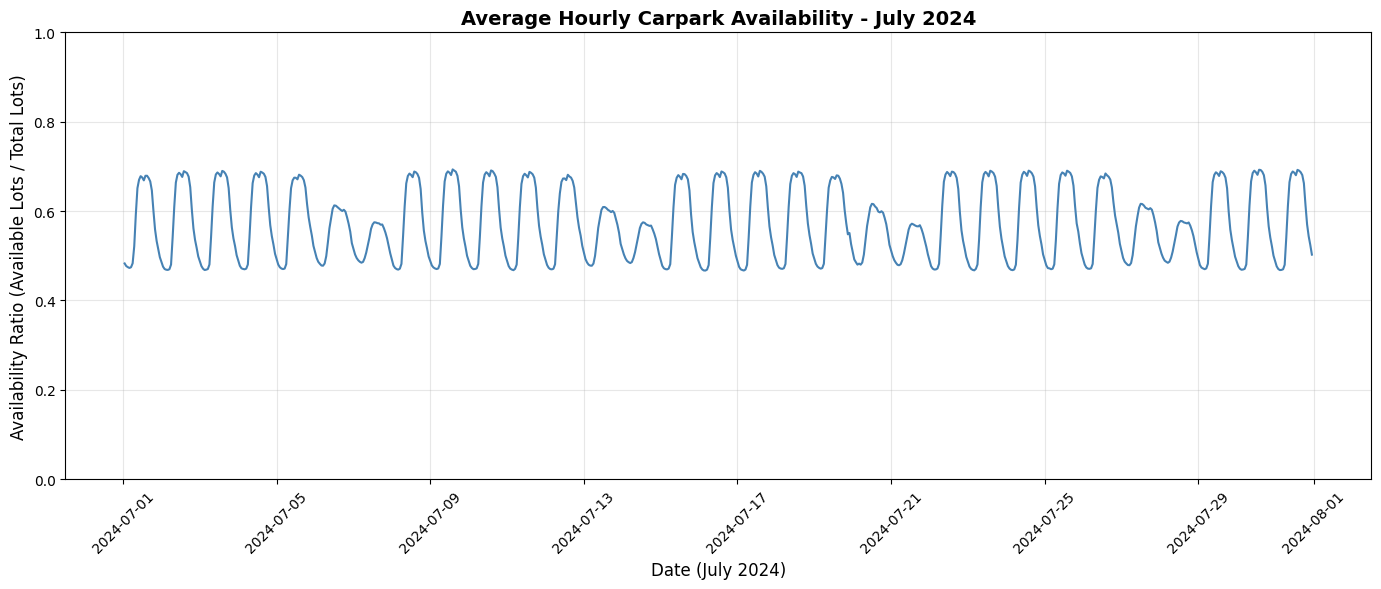

In [ ]:
plt.figure(figsize=(14, 6))
plt.plot(hourly_availability['timestamp'],
         hourly_availability['avg_availability_ratio'],
         linewidth=1.5, color='steelblue')

plt.xlabel('Date (July 2024)', fontsize=12)
plt.ylabel('Availability Ratio (Available Lots / Total Lots)', fontsize=12)
plt.title('Average Hourly Carpark Availability - July 2024', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.ylim(0, 1)
plt.show()

In [ ]:
# Peak hours analysis
hourly_df = july_df.copy()
hourly_df['hour'] = hourly_df['timestamp'].dt.hour

hourly_pattern = hourly_df.groupby('hour').agg({
    'lots_available': 'sum',
    'total_lots': 'sum'
}).reset_index()

hourly_pattern['availability_ratio'] = (
    hourly_pattern['lots_available'] / hourly_pattern['total_lots']
)

print("\nAvailability by Hour of Day:")
print(hourly_pattern)

# Plot daily pattern
plt.figure(figsize=(12, 5))
plt.bar(hourly_pattern['hour'], hourly_pattern['availability_ratio'], color='coral')
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Average Availability Ratio', fontsize=12)
plt.title('Average Carpark Availability by Hour of Day (July 2024)', fontsize=14, fontweight='bold')
plt.xticks(range(0, 24, 2))
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Find peak and off-peak hours
peak_hour = hourly_pattern.loc[hourly_pattern['availability_ratio'].idxmax()]
offpeak_hour = hourly_pattern.loc[hourly_pattern['availability_ratio'].idxmin()]

print(f"\n Patterns Identified:")
print(f"Highest availability: {int(peak_hour['hour'])}:00 ({peak_hour['availability_ratio']:.3f})")
print(f"Lowest availability: {int(offpeak_hour['hour'])}:00 ({offpeak_hour['availability_ratio']:.3f})")


NameError: name 'july_df' is not defined

### 1.4 A carpark may have malfunctioning sensors. There are many types of possible malfunctions. Identify one of these carparks that you believe has a malfunctioning sensors. Explain what the “malfunction” is in this case (about 20 words).

---

Data validation identified three sensor malfunctions: frozen values with no temporal variation, sensors always reporting full availability, and sensors always showing zero availability, all suggesting unrealistic or faulty carpark occupancy data.

For frozen values, Carpark Y77L’s sensor appears faulty, it constantly reports the same availability ratio regardless of time.

In [ ]:
july_df = pd.read_csv('carpark_july_2024.csv')
august_df = pd.read_csv('carpark_august_2024.csv')

In [ ]:
july_df.head()

,timestamp,carpark_number,total_lots,lot_type,lots_available,update_datetime
0,2024-07-01 00:59:27+08:00,HE12,105,C,27,2024-07-01 00:59:01
1,2024-07-01 00:59:27+08:00,HLM,583,C,502,2024-07-01 00:59:11
2,2024-07-01 00:59:27+08:00,RHM,329,C,124,2024-07-01 00:59:02
3,2024-07-01 00:59:27+08:00,BM29,97,C,77,2024-07-01 00:58:51
4,2024-07-01 00:59:27+08:00,Q81,97,C,82,2024-07-01 00:58:51


In [ ]:
# Calculate availability ratio for each carpark-hour combination
july_df['availability_ratio'] = july_df['lots_available'] / july_df['total_lots']

# Group by carpark and calculate variance
carpark_variance = july_df.groupby('carpark_number')['availability_ratio'].var()
carpark_mean = july_df.groupby('carpark_number')['availability_ratio'].mean()
carpark_count = july_df.groupby('carpark_number')['availability_ratio'].count()

# Combine into one dataframe
malfunction_check = pd.DataFrame({
    'variance': carpark_variance,
    'mean_availability': carpark_mean,
    'data_points': carpark_count
}).sort_values('variance')

In [ ]:
# CASE 1: Carparks with extremely low variance (frozen)
print("\nCase 1: Frozen Sensors (Variance < 0.0001)")
frozen = malfunction_check[malfunction_check['variance'] < 0.0001]
print(f"Found {len(frozen)} carparks with frozen sensors\n")
if len(frozen) > 0:
    print(frozen.head(10))
    frozen_carpark = frozen.index[0]
    print(f"\nExample: {frozen_carpark}")
    print(f"  Mean availability: {frozen.loc[frozen_carpark, 'mean_availability']:.4f}")
    print(f"  Variance: {frozen.loc[frozen_carpark, 'variance']:.8f}")
else:
    print("No frozen sensors found\n")

# CASE 2: Carparks stuck at 100% availability
print("\nCase 2: Stuck at 100% Availability (Always Empty)")
always_empty = july_df.groupby('carpark_number')['availability_ratio'].min()
always_empty = always_empty[always_empty > 0.99]
print(f"Found {len(always_empty)} carparks with availability > 99%\n")
if len(always_empty) > 0:
    print(always_empty.head(10))
    empty_carpark = always_empty.index[0]
    print(f"\nExample: {empty_carpark}")
    print(f"  Min availability: {always_empty[empty_carpark]:.4f}")
    print(f"  Max availability: {july_df[july_df['carpark_number'] == empty_carpark]['availability_ratio'].max():.4f}")
else:
    print("No carparks stuck at 100% found\n")

# CASE 3: Carparks stuck at 0% availability
print("\nCase 3: Stuck at 0% Availability (Always Full)")
always_full = july_df.groupby('carpark_number')['availability_ratio'].max()
always_full = always_full[always_full < 0.01]
print(f"Found {len(always_full)} carparks with availability < 1%\n")
if len(always_full) > 0:
    print(always_full.head(10))
    full_carpark = always_full.index[0]
    print(f"\nExample: {full_carpark}")
    print(f"  Max availability: {always_full[full_carpark]:.4f}")
    print(f"  Min availability: {july_df[july_df['carpark_number'] == full_carpark]['availability_ratio'].min():.4f}")
else:
    print("No carparks stuck at 0% found\n")


Case 1: Frozen Sensors (Variance < 0.0001)
Found 72 carparks with frozen sensors

                variance  mean_availability  data_points
carpark_number                                          
Y77L                 0.0           0.500000          713
Y75M                 0.0           0.862797          713
SB27                 0.0           0.716456          713
SB24                 0.0           0.521964          713
SB28                 0.0           0.684739          713
S24L                 0.0           0.000000          713
S19L                 0.0           0.750000          713
B14                  0.0           0.293269          713
TRS                  0.0           0.973978          713
SIM                  0.0           0.930000          713

Example: Y77L
  Mean availability: 0.5000
  Variance: 0.00000000

Case 2: Stuck at 100% Availability (Always Empty)
Found 9 carparks with availability > 99%

carpark_number
B90     1.000000
CC1     1.000000
HG14    1.000000
MP4M    

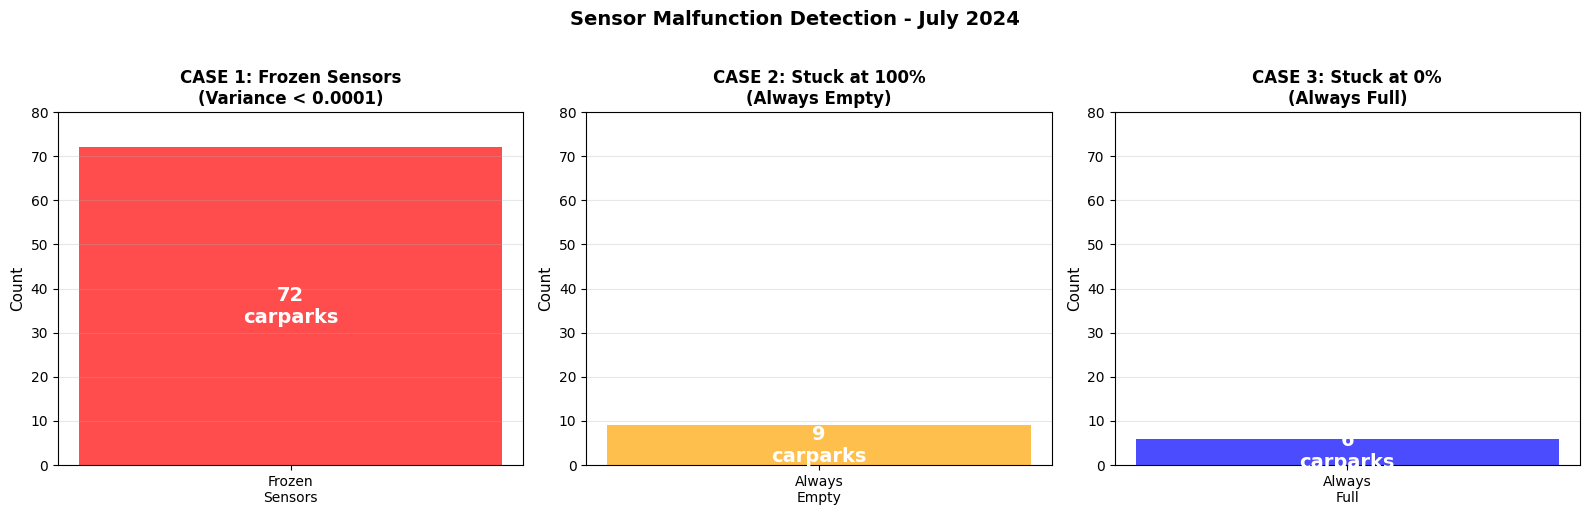

Total Malfunctioning Carparks: 87


In [ ]:
# Simple 3-Panel View of Sensor Malfunctions
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: Frozen Sensors - Show variance distribution
axes[0].bar(['Frozen\nSensors'], [len(frozen)], color='red', alpha=0.7, width=0.4)
axes[0].text(0, len(frozen)/2, f'{len(frozen)}\ncarparks', ha='center', va='center',
             fontsize=14, fontweight='bold', color='white')
axes[0].set_ylabel('Count', fontsize=11)
axes[0].set_title('CASE 1: Frozen Sensors\n(Variance < 0.0001)', fontsize=12, fontweight='bold')
axes[0].set_ylim(0, 80)
axes[0].grid(True, alpha=0.3, axis='y')

# Panel 2: Always Empty - Show availability of stuck carparks
axes[1].bar(['Always\nEmpty'], [len(always_empty)], color='orange', alpha=0.7, width=0.4)
axes[1].text(0, len(always_empty)/2, f'{len(always_empty)}\ncarparks', ha='center', va='center',
             fontsize=14, fontweight='bold', color='white')
axes[1].set_ylabel('Count', fontsize=11)
axes[1].set_title('CASE 2: Stuck at 100%\n(Always Empty)', fontsize=12, fontweight='bold')
axes[1].set_ylim(0, 80)
axes[1].grid(True, alpha=0.3, axis='y')

# Panel 3: Always Full - Show unavailable carparks
axes[2].bar(['Always\nFull'], [len(always_full)], color='blue', alpha=0.7, width=0.4)
axes[2].text(0, len(always_full)/2, f'{len(always_full)}\ncarparks', ha='center', va='center',
             fontsize=14, fontweight='bold', color='white')
axes[2].set_ylabel('Count', fontsize=11)
axes[2].set_title('CASE 3: Stuck at 0%\n(Always Full)', fontsize=12, fontweight='bold')
axes[2].set_ylim(0, 80)
axes[2].grid(True, alpha=0.3, axis='y')

plt.suptitle('Sensor Malfunction Detection - July 2024', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"Total Malfunctioning Carparks: {len(frozen) + len(always_empty) + len(always_full)}")


### 1.6 Intuitively, we expect that carpark availability across certain carparks to be correlated. For example, many housing carparks would experience higher carpark availability during working hours. Using the same interval chosen in 1.5, pick a carpark and find the carpark that is most correlated to it (in terms of carpark availability). State the type of correlation used (e.g. Spearman, Pearson, etc).

---

Selected Carpark: HLM (BLK 533A Hong Lim MSCP)

Calculated Pearson correlation coefficients between its availability and all other carparks in the dataset.

The carpark most correlated to HLM is BM29 (BLK 163 Bukit Merah Central) with:
*   Pearson correlation: 0.8719
*   P-value: 3.02e-219 (highly significant)



**Carpark Details:**
HLM: Hong Lim MSCP, 583 lots, Type C
BM29: Bukit Merah Central, 97 lots, Type C

The strong positive correlation (0.87) indicates that when HLM has more available lots, BM29 tends to have more available lots as well, and vice versa. Both are Type C (car) carparks, likely experiencing similar usage patterns throughout the day.

**Correlation Type Used: Pearson correlation coefficient**

In [ ]:
# Load your July and August carpark availability data
july_df = pd.read_csv('carpark_july_2024.csv')
august_df = pd.read_csv('carpark_august_2024.csv')

# Load the HDB carpark information CSV (from the official site)
carpark_info = pd.read_csv('HDBCarparkInformation.csv')  # update filename as needed

# Only need car_park_no and address
address_df = carpark_info[['car_park_no', 'address']]

# Merge address using carpark_number <-> car_park_no
july_df = july_df.merge(address_df, left_on='carpark_number', right_on='car_park_no', how='left')
august_df = august_df.merge(address_df, left_on='carpark_number', right_on='car_park_no', how='left')

# Drop the unnecessary duplicate key column
july_df = july_df.drop(columns='car_park_no')
august_df = august_df.drop(columns='car_park_no')

# Save the new DataFrames with addresses
july_df.to_csv('carpark_july_2024_with_address.csv', index=False)
august_df.to_csv('carpark_august_2024_with_address.csv', index=False)

print("Address column added to July and August DataFrames. Saved updated files!")
print(july_df.head())


Address column added to July and August DataFrames. Saved updated files!
                   timestamp carpark_number  total_lots lot_type  \
0  2024-07-01 00:59:27+08:00           HE12         105        C   
1  2024-07-01 00:59:27+08:00            HLM         583        C   
2  2024-07-01 00:59:27+08:00            RHM         329        C   
3  2024-07-01 00:59:27+08:00           BM29          97        C   
4  2024-07-01 00:59:27+08:00            Q81          97        C   

   lots_available      update_datetime                      address  
0              27  2024-07-01 00:59:01       BLK 78/81 REDHILL LANE  
1             502  2024-07-01 00:59:11       BLK 533A HONG LIM MSCP  
2             124  2024-07-01 00:59:02        BLK 88A REDHILL CLOSE  
3              77  2024-07-01 00:58:51  BLK 163 BUKIT MERAH CENTRAL  
4              82  2024-07-01 00:58:51         BLK 43 HOLLAND DRIVE  


Target carpark: HLM
Most correlated: BM29
Pearson correlation: 0.8724
P-value: 3.3662e-223

Correlation type: Pearson

--- HLM ---
Address: BLK 533A HONG LIM MSCP
Total Lots: 583
Lot Type: C

--- BM29 ---
Address: BLK 163 BUKIT MERAH CENTRAL
Total Lots: 97
Lot Type: C


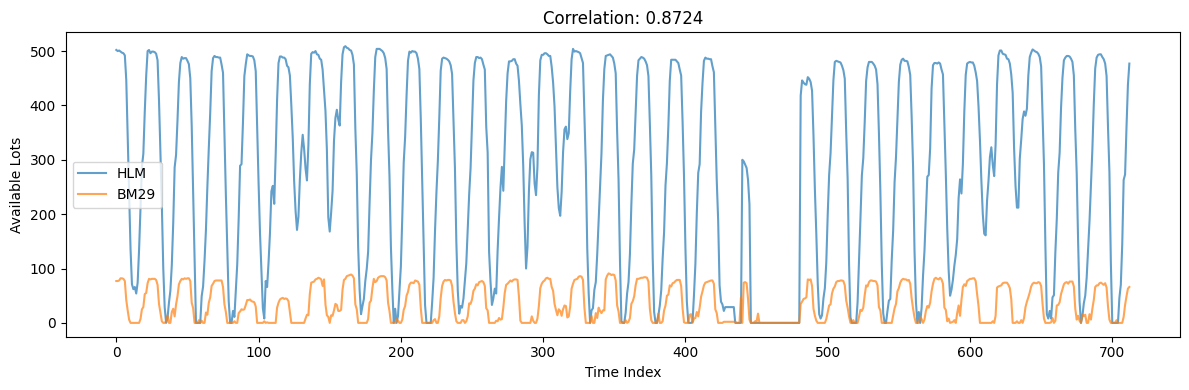

In [ ]:
import pandas as pd
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

# Load and pivot data
df = pd.read_csv('carpark_july_2024_with_address.csv')
pivot_df = df.pivot_table(index='timestamp', columns='carpark_number',
                           values='lots_available', aggfunc='first')

# Pick a carpark
target_carpark = 'HLM'

# Find correlations with all other carparks
correlations = []
target_data = pivot_df[target_carpark].dropna()

for carpark in pivot_df.columns:
    if carpark != target_carpark:
        other_data = pivot_df[carpark].dropna()
        common_idx = target_data.index.intersection(other_data.index)

        if len(common_idx) > 10:
            # Skip if either series is constant
            if target_data[common_idx].std() == 0 or other_data[common_idx].std() == 0:
                continue

            corr, p_val = pearsonr(target_data[common_idx], other_data[common_idx])
            correlations.append({
                'carpark': carpark,
                'correlation': corr,
                'p_value': p_val
            })

# Find most correlated
corr_df = pd.DataFrame(correlations).sort_values('correlation', ascending=False)
top = corr_df.iloc[0]

print(f"Target carpark: {target_carpark}")
print(f"Most correlated: {top['carpark']}")
print(f"Pearson correlation: {top['correlation']:.4f}")
print(f"P-value: {top['p_value']:.4e}")
print(f"\nCorrelation type: Pearson")

# Get carpark details
target_info = df[df['carpark_number'] == target_carpark].iloc[0]
correlated_info = df[df['carpark_number'] == top['carpark']].iloc[0]

print(f"\n--- {target_carpark} ---")
print(f"Address: {target_info['address']}")
print(f"Total Lots: {target_info['total_lots']}")
print(f"Lot Type: {target_info['lot_type']}")

print(f"\n--- {top['carpark']} ---")
print(f"Address: {correlated_info['address']}")
print(f"Total Lots: {correlated_info['total_lots']}")
print(f"Lot Type: {correlated_info['lot_type']}")

# Visualize
common_idx = target_data.index.intersection(pivot_df[top['carpark']].dropna().index)
plt.figure(figsize=(12, 4))
plt.plot(target_data[common_idx].values, label=target_carpark, alpha=0.7)
plt.plot(pivot_df[top['carpark']][common_idx].values, label=top['carpark'], alpha=0.7)
plt.xlabel('Time Index')
plt.ylabel('Available Lots')
plt.legend()
plt.title(f"Correlation: {top['correlation']:.4f}")
plt.tight_layout()
plt.show()

### 1.7 Group Project Proposal for Question 3: Please include a short proposal (around 500 words) of what your team intends to do for the Group Proposed Project in Question 3. For the group project proposal, you may use additional datasets to supplement your analysis or look at unaggregated data, etc. See Question 3 below for more information about this. Please use markdown in the iPython notebook to present your proposal.

----

## Group Project Proposal — Weather Impact on Carpark Availability Patterns

### **Project Goal**

This project investigates how weather conditions influence parking availability across Singapore carparks and develops predictive models to forecast parking space availability at individual locations. We combine parking data from HDB and LTA carparks with weather information from the National Environment Agency (NEA) covering July through August 2024. The goal is to create accurate forecasting tools that help both drivers and urban planners make better decisions.

### **Datasets**

The primary dataset consists of timestamped records from the LTA DataMall API showing available parking spaces at each carpark throughout the study period. We supplement this with NEA weather data from data.gov.sg, including historical forecasts and real time observations of temperature, humidity, rainfall, wind conditions, and general weather descriptions. To address gaps between weather station locations, we may incorporate data from the Open Meteo historical weather API. Carparks will be matched to nearby weather stations using geographic coordinates, and we will categorize facilities as outdoor or covered based on available metadata.

### **Research Questions**

Our analysis addresses three core questions. First, we examine how weather variables such as rainfall, temperature, humidity, and wind affect parking availability across different carpark types and times of day. Second, we evaluate whether incorporating weather data into forecasting models improves prediction accuracy compared to models relying solely on historical parking patterns. Third, we identify which carparks are most sensitive to weather changes and explore how these predictions can benefit drivers and parking facility managers.

### **Methodology**

We begin with exploratory data analysis to understand baseline patterns. This includes examining how parking availability varies by time of day and day of week, comparing parking behavior during rainy periods against the unusual dry spell that occurred July 13 through 30, visualizing relationships between weather conditions and parking occupancy, and investigating whether weather effects appear immediately or with time delays.

Next, we engineer features that capture relevant patterns. Time based features include hour of day, day of week, and public holidays. We compute rolling averages to capture recent parking trends and create weather variables indicating rainfall amount, presence of rain, temperature, and humidity levels. Combined features such as outdoor carpark interacted with rainfall help capture situation specific impacts. We also incorporate short term weather forecasts spanning 2 to 6 hours ahead.

For modeling, we establish baseline models using persistence forecasting (assuming availability remains constant) and ARIMA (AutoRegressive Integrated Moving Average), which detects seasonal patterns statistically. Machine learning approaches include XGBoost and LightGBM, which are gradient boosted tree algorithms that automatically identify complex relationships between weather and parking patterns. For high traffic carparks with substantial data volume, we apply deep learning architectures including LSTM (Long Short Term Memory networks), which excel at capturing sequential dependencies in time series data.

Model validation follows time series best practices using walk forward cross validation, where we always train on past data and test on future periods. We perform split validation training on July and testing on August, and vice versa, which helps evaluate model robustness during Singapore's atypical July dry weather. Performance metrics include MAE (Mean Absolute Error), RMSE (Root Mean Squared Error), and MAPE (Mean Absolute Percentage Error) measured at 15, 30, and 60 minute forecast horizons.

### **Practical Implications**

For government agencies including URA (Urban Redevelopment Authority) and HDB (Housing & Development Board), this work provides long term planning insights by identifying weather vulnerable locations that may require covered parking infrastructure and supporting data driven decisions about capacity expansion. In the short term, findings enable policy applications such as surge pricing or demand based pricing during peak weather affected periods, which can manage availability, encourage off peak usage, and optimize existing infrastructure without immediate construction investments. For drivers, real time forecasts help locate available parking during adverse weather events, reducing search time and traffic congestion.